In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("restaurant_chains_2000_rows.csv")

df.head()

df.info()

chain_counts = df["name"].value_counts()

restaurant_chains = chain_counts[chain_counts > 1]

chain_df = df[df["name"].isin(restaurant_chains.index)]

summary = chain_df.groupby("name").agg(
    avg_rating=("rate", "mean"),
    avg_votes=("votes", "mean")
).sort_values(by="avg_rating", ascending=False)

print("\nRestaurant Chains Analysis:\n")
print(summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         2000 non-null   object 
 1   rate                         2000 non-null   float64
 2   votes                        2000 non-null   int64  
 3   location                     2000 non-null   object 
 4   cuisines                     2000 non-null   object 
 5   approx_cost(for two people)  2000 non-null   int64  
 6   online_order                 2000 non-null   object 
 7   book_table                   2000 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 125.1+ KB

Restaurant Chains Analysis:

                   avg_rating    avg_votes
name                                      
Subway               4.111801  1251.968944
Empire Restaurant    4.102069  1300.386207
Burger King          4.074545  1360.018182
Domin

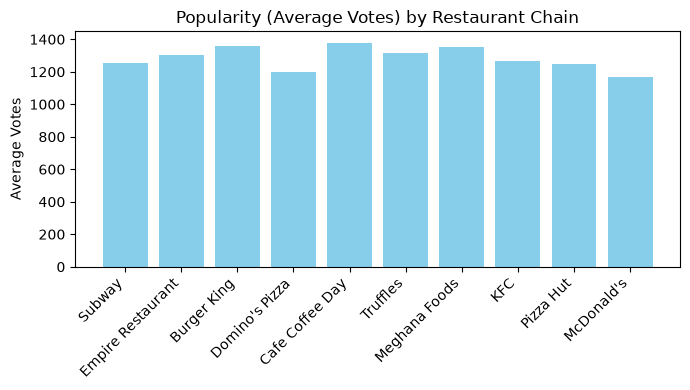

In [13]:
plt.figure(figsize=(7,4))
plt.bar(summary.index, summary["avg_votes"], color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Votes")
plt.title("Popularity (Average Votes) by Restaurant Chain")
plt.tight_layout()
plt.show()

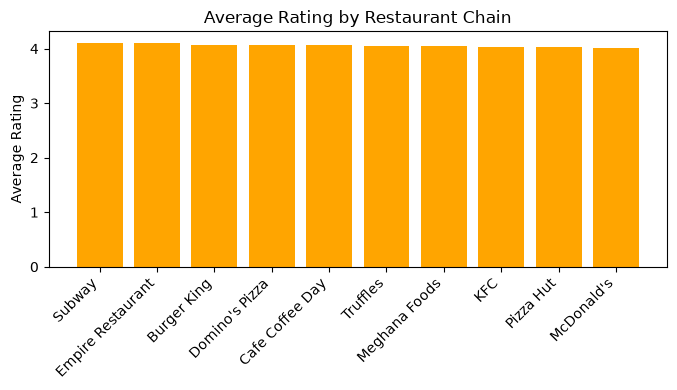

In [14]:
plt.figure(figsize=(7,4))
plt.bar(summary.index, summary["avg_rating"], color="orange")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Rating")
plt.title("Average Rating by Restaurant Chain")
plt.tight_layout()
plt.show()